<a href="https://colab.research.google.com/github/dsaoulis/Thesis/blob/main/OLR_with_Super_Soft_WLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------------------------------------------------------------------------------
1. ΕΓΚΑΤΑΣΤΑΣΗ ΠΑΚΕΤΩΝ
--------------------------------------------------------------------------------
✓ pandas already installed
✓ numpy already installed
✓ matplotlib already installed
✓ seaborn already installed
↓ Installing scikit-learn...
✓ scikit-learn installed
✓ statsmodels already installed
✓ scipy already installed
✓ openpyxl already installed

✓ Όλα τα πακέτα εισήχθησαν με επιτυχία


--------------------------------------------------------------------------------
2. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΑΠΟ ΤΟ EXCEL
--------------------------------------------------------------------------------
✓ Φορτωμένα Δεδομένα: 719 σειρές, 8 στήλες


--------------------------------------------------------------------------------
3. ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ, PD MAPPING & LOGIT ΜΕΤΑΣΧΗΜΑΤΙΣΜΟΣ
--------------------------------------------------------------------------------
Διανομή Group:
Group
Group 3 (BBB)       378
Group 2 

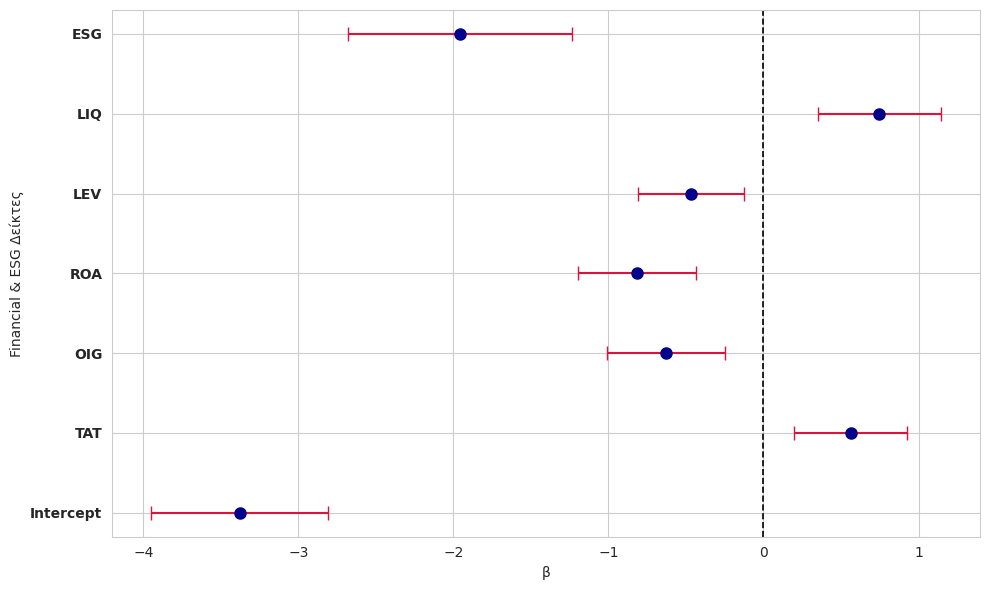



--------------------------------------------------------------------------------
8. ΑΞΙΟΛΟΓΗΣΗ ΜΟΝΤΕΛΟΥ ΑΠ0ΔΟΣΗΣ PD %
--------------------------------------------------------------------------------
✓ Train R-squared (R²)         : 0.0182
✓ Test R-squared (R²)          : -0.0547
✓ Test Root Mean Squared Error: 1.9951 % PD
✓ Test Mean Absolute Error     : 0.9117 % PD


--------------------------------------------------------------------------------
9. MAPPING ΣΤΑ 4 GROUPS & ΑΚΡΙΒΕΙΑ (EXACT VS TOLERANCE)
--------------------------------------------------------------------------------
─────────────────────────────────────────────────────────────────────────────────────
🎯 ΣΥΝΟΛΙΚΟ EXACT GROUP ACCURACY                       : 55.71%
📈 ΣΥΝΟΛΙΚΟ ACCURACY ΜΟΝΤΕΛΟΥ     (Με ανοχή ±1 Group)  : 96.43%
─────────────────────────────────────────────────────────────────────────────────────
Όνομα Group          | Δείγμα | Exact Group    | Tolerance ±1 Group  
─────────────────────────────────────────

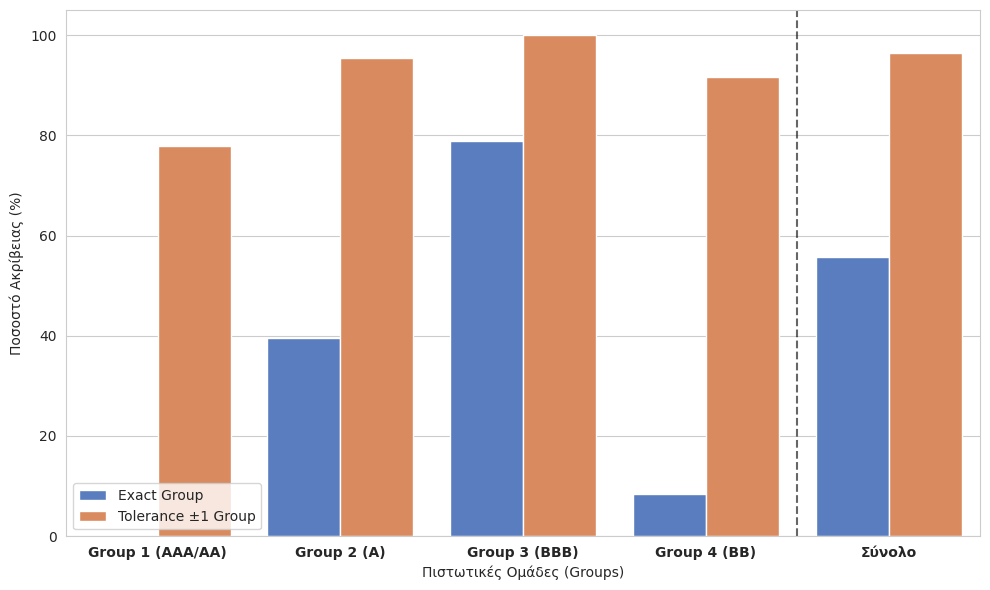

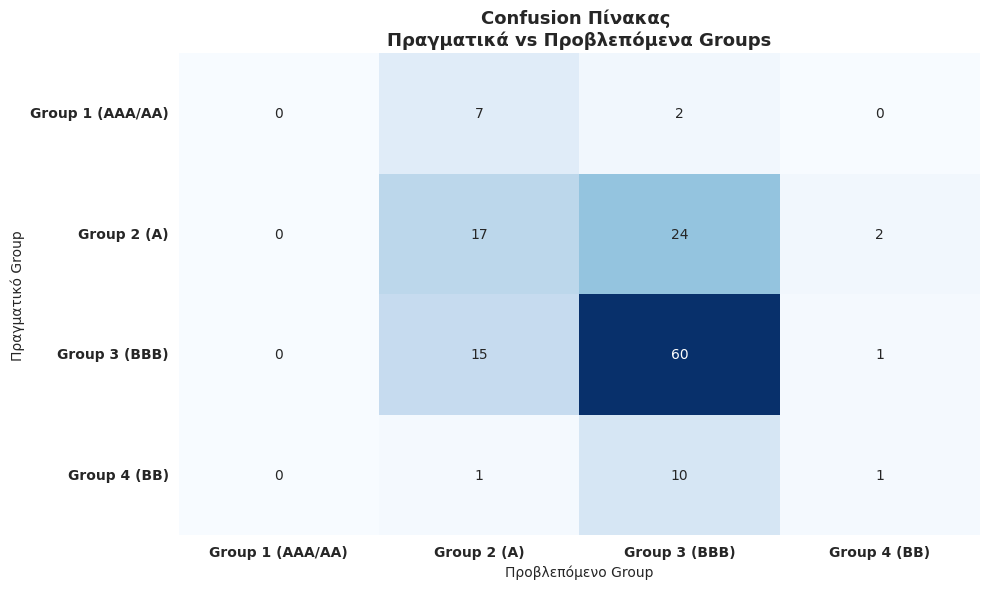

In [ ]:
# --------------------------------------------------------------------------------
# Z-Function & PD Calibration Model
# Ordinal Logistic Regression with Super Soft Weighted Least Squares
# --------------------------------------------------------------------------------

# --------------------------------------------------------------------------------
# 1. INSTALL REQUIRED PACKAGES
# --------------------------------------------------------------------------------
import subprocess
import sys

def install_packages():
    """Install required packages"""
    packages = [
        'pandas', 'numpy', 'matplotlib', 'seaborn',
        'scikit-learn', 'statsmodels', 'scipy', 'openpyxl'
    ]
    for package in packages:
        try:
            __import__(package.replace('-', '_'))
            print(f"✓ {package} already installed")
        except ImportError:
            print(f"↓ Installing {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
            print(f"✓ {package} installed")

print("-" * 80)
print("1. ΕΓΚΑΤΑΣΤΑΣΗ ΠΑΚΕΤΩΝ")
print("-" * 80)
install_packages()

# --------------------------------------------------------------------------------
# 2. IMPORT LIBRARIES
# --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("\n✓ Όλα τα πακέτα εισήχθησαν με επιτυχία")

# --------------------------------------------------------------------------------
# 3. LOAD DATA FROM EXCEL
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("2. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΑΠΟ ΤΟ EXCEL")
print("-" * 80)

# Φόρτωση EXCEL από το dropbox μου
dropbox_url = "https://www.dropbox.com/scl/fi/ridnctbeg4tdjsr16cbpl/NORMALIZED-INDICATORS.xlsx?rlkey=96fvv6xnnwampnsm6gb1055k7&st=ujqqamyv&dl=1"
df = pd.read_excel(dropbox_url, sheet_name='ΣΥΝΟΛΙΚΑ 3')

print(f"✓ Φορτωμένα Δεδομένα: {df.shape[0]} σειρές, {df.shape[1]} στήλες")

# --------------------------------------------------------------------------------
# 4. DATA PREPROCESSING, PD MAPPING & LOGIT TRANSFORMATION
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("3. ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ, PD MAPPING & LOGIT ΜΕΤΑΣΧΗΜΑΤΙΣΜΟΣ")
print("-" * 80)

# Ορισμός Δεικτών και Rating
predictors = ['TAT', 'OIG', 'ROA', 'LEV', 'LIQ', 'ESG_Score']
target = 'S&P Credit Rating'
valid_ratings = ['AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-', 'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-']

# Έλεγχος εγκυρότητάς τους
df_work = df[[*predictors, target]].copy().dropna().drop_duplicates()
df_work.columns = ['TAT', 'OIG', 'ROA', 'LEV', 'LIQ', 'ESG', 'Rating']
df_work['Rating'] = df_work['Rating'].astype(str).str.strip()
df_work = df_work[df_work['Rating'].isin(valid_ratings)].copy()

# Δημιουργία των 4 Groups
group_mapping = {
    'AAA': 'Group 1 (AAA/AA)', 'AA+': 'Group 1 (AAA/AA)', 'AA': 'Group 1 (AAA/AA)', 'AA-': 'Group 1 (AAA/AA)',
    'A+': 'Group 2 (A)', 'A': 'Group 2 (A)', 'A-': 'Group 2 (A)',
    'BBB+': 'Group 3 (BBB)', 'BBB': 'Group 3 (BBB)', 'BBB-': 'Group 3 (BBB)',
    'BB+': 'Group 4 (BB)', 'BB': 'Group 4 (BB)', 'BB-': 'Group 4 (BB)',
}

# Ορισμός της μέσης τιμής του PD για τα Groups
group_pd_mapping = {
    'Group 1 (AAA/AA)': 0.1,
    'Group 2 (A)': 0.25,
    'Group 3 (BBB)': 1.0,
    'Group 4 (BB)': 7.5
}

# Ιεράρχηση Ratings και Groups
ordered_ratings = ['AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-', 'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-']
group_order = ['Group 1 (AAA/AA)', 'Group 2 (A)', 'Group 3 (BBB)', 'Group 4 (BB)']

# Ορισμός των PD ευρών για τα Ratings
pd_ranges = {
    'AAA': (0.00, 0.04),   'AA+': (0.05, 0.08),   'AA': (0.09, 0.12),
    'AA-': (0.13, 0.16),   'A+': (0.17, 0.28),    'A': (0.29, 0.41),
    'A-': (0.42, 0.54),    'BBB+': (0.55, 1.16),  'BBB': (1.17, 1.77),
    'BBB-': (1.78, 2.39),  'BB+': (2.40, 5.26),   'BB': (5.27, 8.12),
    'BB-': (8.13, 10.99)
}

# Ορισμός PD σε Rating
def pd_to_rating_label(pd_value):
    for rating, (low, high) in pd_ranges.items():
        if low <= pd_value <= high:
            return rating
    if pd_value < 0: return 'AAA'
    return 'BB-'

df_work['Assigned_Group'] = df_work['Rating'].map(group_mapping)
df_work['PD_Mean'] = df_work['Assigned_Group'].map(group_pd_mapping)
df_work = df_work.dropna(subset=['PD_Mean'])

# Μετατροπη σε δεκαδική μορφή
df_work['PD_decimal'] = df_work['PD_Mean'] / 100
eps = 1e-6
df_work['PD_decimal'] = df_work['PD_decimal'].clip(eps, 1 - eps)

# Logit Μετασχηματισμός
df_work['Z_target'] = np.log(df_work['PD_decimal'] / (1 - df_work['PD_decimal']))

df_work['Group'] = df_work['Rating'].map(group_mapping)
df_work = df_work[df_work['Group'].notna()]

print(f"Διανομή Group:\n{df_work['Group'].value_counts()}")
print(f"\nΔιανομή Rating:\n{df_work['Rating'].value_counts()}")

print(f"\n✓ Ολοκληρώθηκαν Mapping & Logit Μετασχηματισμός. Dataset μέγεθος: {df_work.shape[0]} εταιρείες")

# --------------------------------------------------------------------------------
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("4. EXPLORATORY DATA ANALYSIS (EDA)")
print("-" * 80)

# Ανάλυση συσχέτισης με Spearman
corr_matrix = df_work[['TAT', 'OIG', 'ROA', 'LEV', 'LIQ', 'ESG', 'PD_Mean']].corr(method='spearman')
print("Πίνακας Συσχέτισης Spearman:")
print(corr_matrix['PD_Mean'].to_string())

# --------------------------------------------------------------------------------
# 6. TRAIN-TEST SPLIT
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("5. TRAIN-TEST SPLIT")
print("-" * 80)

X = df_work[['TAT', 'OIG', 'ROA', 'LEV', 'LIQ', 'ESG']].copy()
y = df_work['Z_target'].copy()

y_groups = df_work['Assigned_Group']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_groups
)

X_train = sm.add_constant(X_train_raw)
X_test = sm.add_constant(X_test_raw)

print(f"✓ Training set: {X_train.shape[0]} εταιρείες")
print(f"✓ Test set: {X_test.shape[0]} εταιρείες")

# --------------------------------------------------------------------------------
# 7. CALIBRATING Z-FUNCTION WEIGHTS VIA WLS (WEIGHTED LEAST SQUARES)
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("6. ΠΡΟΣΑΡΜΟΓΗ WLS ΓΙΑ ΤΗΝ ΙΣΟΡΡΟΠΙΑ ΤΗΣ ΑΚΡΙΒΕΙΑΣ ΣΤΙΣ ΟΜΑΔΕΣ")
print("-" * 80)

train_groups = df_work.loc[y_train.index, 'Assigned_Group'].values

from collections import Counter
group_counts_train = Counter(train_groups)
total_train = len(train_groups)

# Χρήση p=0.1 έπειτα απο δοκιμές με διάφορες τιμες του p
p = 0.1
weights_vector = []
for g in train_groups:
    freq = group_counts_train[g] / total_train
    w = (1.0 / freq) ** p
    weights_vector.append(w)

weights_vector = np.array(weights_vector)
weights_vector = weights_vector * (len(weights_vector) / np.sum(weights_vector))

wls_model = sm.WLS(y_train, X_train, weights=weights_vector)
result = wls_model.fit()

# Εκτύπωση WLS ανάλυσης
print(result.summary())

print("\n\n" + "-"*80)
print("7. ΤΑ ΝΕΑ ΒΑΡΗ (β) ΜΕ ΤΗ ΜΕΘΟΔΟ WLS (p=0.1):")
print("-"*80)

# Εκτιμήσεις βαρών
for feature, weight in result.params.items():
    name = "β_0 (Intercept)" if feature == 'const' else f"β_{feature}"
    print(f"{name:20} : {weight:.6f}")

# Διάγραμμα εκτίμησης βαρών με 95% διάστημα εμπιστοσύνης
plt.figure(figsize=(10, 6))
coef_df = pd.DataFrame({
    'Feature': result.params.index,
    'Coefficient': result.params.values,
    'Lower CI': result.conf_int()[0].values,
    'Upper CI': result.conf_int()[1].values
})
coef_df['Error'] = coef_df['Coefficient'] - coef_df['Lower CI']
coef_df['Feature'] = coef_df['Feature'].replace('const', 'Intercept')

plt.errorbar(x=coef_df['Coefficient'], y=coef_df['Feature'], xerr=coef_df['Error'],
             fmt='o', color='darkblue', ecolor='crimson', capsize=5, markersize=8)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
plt.xlabel('β')
plt.ylabel('Financial & ESG Δείκτες')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------
# 8. MODEL PREDICTIONS AND PERFORMANCE (CONVERTING BACK TO PD %)
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("8. ΑΞΙΟΛΟΓΗΣΗ ΜΟΝΤΕΛΟΥ ΑΠ0ΔΟΣΗΣ PD %")
print("-" * 80)

z_pred_train = result.predict(X_train)
z_pred_test = result.predict(X_test)

y_pred_train_pd = (1 / (1 + np.exp(-z_pred_train))) * 100
y_pred_test_pd = (1 / (1 + np.exp(-z_pred_test))) * 100

y_train_original_pd = df_work.loc[y_train.index, 'PD_Mean']
y_test_original_pd = df_work.loc[y_test.index, 'PD_Mean']

r2_train = r2_score(y_train_original_pd, y_pred_train_pd)
r2_test = r2_score(y_test_original_pd, y_pred_test_pd)
rmse_test = np.sqrt(mean_squared_error(y_test_original_pd, y_pred_test_pd))
mae_test = mean_absolute_error(y_test_original_pd, y_pred_test_pd)

print(f"✓ Train R-squared (R²)         : {r2_train:.4f}")
print(f"✓ Test R-squared (R²)          : {r2_test:.4f}")
print(f"✓ Test Root Mean Squared Error: {rmse_test:.4f} % PD")
print(f"✓ Test Mean Absolute Error     : {mae_test:.4f} % PD")

# --------------------------------------------------------------------------------
# 9. 4-GROUP MAPPING ΜΕ ΑΚΡΙΒΕΙΑ (EXACT VS TOLERANCE ±1 GROUP)
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("9. MAPPING ΣΤΑ 4 GROUPS & ΑΚΡΙΒΕΙΑ (EXACT VS TOLERANCE)")
print("-" * 80)

actual_ratings = df_work.loc[y_test.index, 'Rating'].values
predicted_ratings = [pd_to_rating_label(val) for val in y_pred_test_pd.values]

group_counts = {g: 0 for g in group_order}
group_correct_exact_group = {g: 0 for g in group_order}
group_correct_category = {g: 0 for g in group_order}

correct_total_exact_group = 0
correct_total_category = 0

raw_pred_groups = []
raw_actual_groups = []

for act_r, pred_r, pred_pd_val in zip(actual_ratings, predicted_ratings, y_pred_test_pd.values):
    # Αντιμετώπιση αγνώστων ratings
    if pred_r not in ordered_ratings: pred_r = 'BB-'
    if act_r not in ordered_ratings: act_r = 'BB-'

    act_group = group_mapping.get(act_r, 'Group 4 (BB)')
    pred_group = group_mapping.get(pred_r, 'Group 4 (BB)')

    raw_actual_groups.append(act_group)
    raw_pred_groups.append(pred_group)

    # 1. Exact Group Match
    is_exact_group = (act_group == pred_group)

    # 2. Tolerance ±1 Group Match
    group_idx = group_order.index(act_group)
    allowed_groups_by_category = [act_group]
    if group_idx > 0: allowed_groups_by_category.append(group_order[group_idx - 1])
    if group_idx < len(group_order) - 1: allowed_groups_by_category.append(group_order[group_idx + 1])

    is_correct_category = pred_group in allowed_groups_by_category

    # Ειδική συνθήκη ανοχής για το Group 4
    if act_group == 'Group 4 (BB)' and 11.0 <= pred_pd_val <= 26.5:
        is_correct_category = True

    # Καταγραφή
    group_counts[act_group] += 1
    if is_exact_group: correct_total_exact_group += 1; group_correct_exact_group[act_group] += 1
    if is_correct_category: correct_total_category += 1; group_correct_category[act_group] += 1

n_samples = len(actual_ratings)
acc_exact_group = (correct_total_exact_group / n_samples) * 100
acc_total_category = (correct_total_category / n_samples) * 100


print("─" * 85)
print(f"🎯 ΣΥΝΟΛΙΚΟ EXACT GROUP ACCURACY                       : {acc_exact_group:.2f}%")
print(f"📈 ΣΥΝΟΛΙΚΟ ACCURACY ΜΟΝΤΕΛΟΥ     (Με ανοχή ±1 Group)  : {acc_total_category:.2f}%")
print("─" * 85)

header = f"{'Όνομα Group':<20} | {'Δείγμα':<6} | {'Exact Group':<14} | {'Tolerance ±1 Group':<20}"
print(header)
print("─" * 85)

accuracy_records = []
for g in group_order:
    total_in_g = group_counts[g]
    if total_in_g > 0:
        pct_ex_grp = (group_correct_exact_group[g] / total_in_g) * 100
        pct_cat = (group_correct_category[g] / total_in_g) * 100

        print(f"{g:<20} | {total_in_g:<6} | "
              f"{pct_ex_grp:>8.1f}% ({group_correct_exact_group[g]:<2}){'':<{0}} | "
              f"{pct_cat:>8.1f}% ({group_correct_category[g]:<2}) {'':<{0}} ")

        accuracy_records.append({
            'Group': g,
            'Exact Group': pct_ex_grp,
            'Tolerance ±1 Group': pct_cat
        })
    else:
        print(f"{g:<20} | {total_in_g:<6} | {'Δεν υπάρχουν δεδομένα στο test set':<40}")
print("─" * 85)

# Προσθήκη του Συνόλου στο γράφημα
accuracy_records.append({
    'Group': 'Σύνολο',
    'Exact Group': acc_exact_group,
    'Tolerance ±1 Group': acc_total_category
})

# Διάγραμμα ακρίβειας (Μόνο για Groups)
if accuracy_records:
    df_acc_plot = pd.DataFrame(accuracy_records)
    df_acc_melted = df_acc_plot.melt(id_vars='Group', var_name='Metric', value_name='Accuracy %')

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_acc_melted, x='Group', y='Accuracy %', hue='Metric', palette='muted')
    plt.axvline(x=3.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    plt.xlabel('Πιστωτικές Ομάδες (Groups)')
    plt.ylabel('Ποσοστό Ακρίβειας (%)')
    plt.ylim(0, 105)
    plt.legend(loc='lower left', frameon=True)
    plt.xticks(fontweight='bold')
    plt.tight_layout()
    plt.show()

# Confusion Πίνακας
unique_groups = [g for g in group_order if g in set(raw_actual_groups + raw_pred_groups)]
cm_groups = confusion_matrix(raw_actual_groups, raw_pred_groups, labels=unique_groups)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_groups, annot=True, fmt='d', cmap='Blues', xticklabels=unique_groups, yticklabels=unique_groups, cbar=False)
plt.title('Confusion Πίνακας \nΠραγματικά vs Προβλεπόμενα Groups', fontsize=13, fontweight='bold')
plt.xlabel('Προβλεπόμενο Group')
plt.ylabel('Πραγματικό Group')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold', rotation=0)
plt.tight_layout()
plt.show()